In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
post_opto = ['BS_86','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174']
post_control = ['AE_267','AO_273','AE_287','AE_312']

all_animals = np.concatenate([post_opto, post_control])

In [3]:
df = pd.read_csv('../../Source Data Files/Figure 3i.csv')

In [4]:
df

,Unnamed: 0,animal,hits,misses,false alarms,correct rejects,condition
0,0,BS_86,78.947519,21.052481,79.106690,20.893310,opto
1,1,BS_119,88.175509,11.824491,92.852552,7.147448,opto
2,2,BS_123,85.946329,14.053671,85.033725,14.966275,opto
3,3,BS_128,58.895310,41.104690,64.650280,35.349720,opto
4,4,BS_131,80.985384,19.014616,84.938591,15.061409,opto
5,5,BS_163,86.944779,13.055221,85.793276,14.206724,opto
6,6,BS_174,97.090100,2.909900,97.632204,2.367796,opto
7,7,AE_267,89.349376,10.650624,24.255952,75.744048,control
8,8,AO_273,99.305556,0.694444,54.615385,45.384615,control
9,9,AE_287,93.881146,6.118854,39.067669,60.932331,control


In [5]:
opsin_hits = []
opsin_misses = []
opsin_falarms = []
opsin_crejects = []

control_hits = []
control_misses = []
control_falarms = []
control_crejects = []

for row in df.iloc:
    if row['condition'] == 'opto':
        opsin_hits.append(row['hits'])
        opsin_misses.append(row['misses'])
        opsin_falarms.append(row['false alarms'])
        opsin_crejects.append(row['correct rejects'])
    if row['condition'] == 'control':
        control_hits.append(row['hits'])
        control_misses.append(row['misses'])
        control_falarms.append(row['false alarms'])
        control_crejects.append(row['correct rejects'])

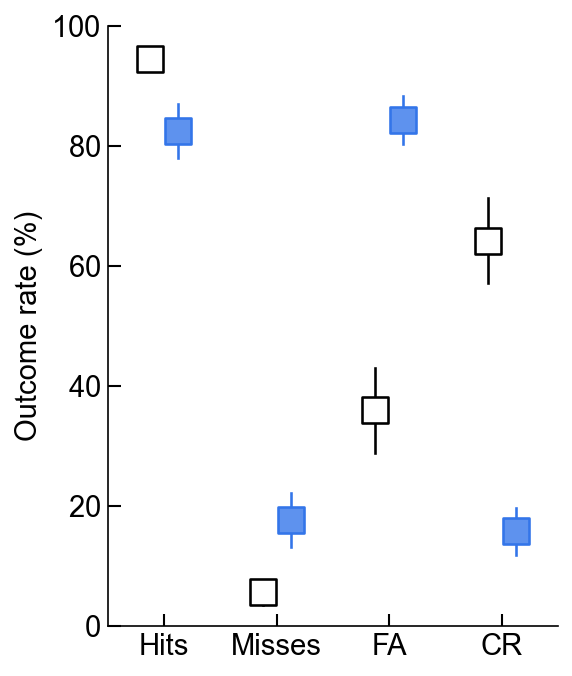

In [6]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(3, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25
meanwidth = 0.25

################################################################################################################

for idx,(control_data,opsin_data) in enumerate(zip([control_hits,control_misses,control_falarms,control_crejects],[opsin_hits,opsin_misses,opsin_falarms,opsin_crejects])):
    control_data = ilep.rmnan(control_data)
    opsin_data = ilep.rmnan(opsin_data)
    control_mean = np.mean(control_data)
    opsin_mean = np.mean(opsin_data)
    control_sem = sem(control_data)
    opsin_sem = sem(opsin_data)
    ax.plot([idx-0.125]*2,[control_mean-control_sem,control_mean+control_sem],color='k',lw=1.25)
    ax.plot([idx+0.125]*2,[opsin_mean-opsin_sem,opsin_mean+opsin_sem],color=LASER_COLOR,lw=1.25)
    ax.scatter([idx-0.125],[control_mean],s=150,ec='k',fc='white',zorder=10,lw=1.25,marker='s')
    ax.scatter([idx+0.125],[opsin_mean],s=150,ec=LASER_COLOR,fc=LIGHT_LASER,zorder=10,lw=1.25,marker='s')

################################################################################################################

labels = ['Control','Opto']

ax.set_ylim([0,100])
ylab = ax.set_ylabel('Outcome rate (%)')

ax.set_xlim(-0.5,3.5)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['Hits','Misses','FA','CR'])

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)

artists = [ylab]
# fig.savefig(os.path.join('D:\\\\Figures','Manuscript Figures','Opsin trial outcomes at cutoff V'+str(current_version)+'.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [10]:
p1 = ttest_ind(ilep.rmnan(control_hits),ilep.rmnan(opsin_hits)).pvalue
p2 = ttest_ind(ilep.rmnan(control_misses),ilep.rmnan(opsin_misses)).pvalue
p3 = ttest_ind(ilep.rmnan(control_falarms),ilep.rmnan(opsin_falarms)).pvalue
p4 = ttest_ind(ilep.rmnan(control_crejects),ilep.rmnan(opsin_crejects)).pvalue
_,pvals = pg.multicomp([p1,p2,p3,p4],method='fdr_bh')

print('Opto vs control')
print(f'Hits: p = {pvals[0]}')
print(f'Misses: p = {pvals[1]}')
print(f'False alarms: p = {pvals[2]}')
print(f'Correct rejects: p = {pvals[3]}')

Opto vs control
Hits: p = 0.08761870328766148
Misses: p = 0.08761870328766148
False alarms: p = 0.0002224220308577885
Correct rejects: p = 0.0002224220308577885
